In [ ]:
import numpy as np
import plumed
import matplotlib.pyplot as plt
import os
from scipy import stats
from scipy.spatial.distance import jensenshannon
import seaborn as sns
def get_cvname(filename):
    data = plumed.read_as_pandas(filename)
    cv_name = []
    for i in data.columns[1:]:
        if i.startswith('e') or i.startswith('sin') or i.startswith('cos'):
            pass
        else:
            cv_name.append(i)
    return cv_name

def calculate_distribution(cv_name, colvar,sigma=0.1):
    try:
        os.mkdir("FES")
    except FileExistsError:
        pass
    for cv in cv_name:
        cv_str = ",".join(cv)
        sigmas = [sigma for _ in range(len(cv))]
        sigmas = ",".join(map(str, sigmas))
        print(sigmas)
        os.system(f"rm -rf /workdir/AgOR10_28/AgOR10/PCCA2/FES/FES_{colvar}_{cv_str}.dat")
        os.system(f"python /root/FES_from_Reweighting.py -f /workdir/AgOR10_28/AgOR10/PCCA2/COLVAR_S5_upper{colvar} -o /workdir/AgOR10_28/AgOR10/PCCA2/FES/FES_S5_upper{colvar}_{cv_str}.dat --sigma {sigmas} --temp 310 --cv {cv_str} --bin 20,20 --bias no")

cv_names = [['open_rmsd','close_rmsd']]
state_indices = [0, 1, 2, 3, 4, 5]
print("Calculating distributions...")
for idx in state_indices:
    calculate_distribution(cv_names, str(idx))

In [ ]:
def plot_all_distributions(cv_name, filenames,indices, output_file=None):
    plt.figure(figsize=(12, 7))

    colors = [
    "#F6C667",  # soft gold
    "#B8A1E3",
      "#00F56A",  # light lavender
        "#0D11F0",  # mint-teal
        ]
    kb = 0.0083145
    T = 310
    kbT = kb * T
    sns.set_theme(style="ticks") 
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.size': 12,
        'axes.linewidth': 1.5,
        'xtick.major.width': 1.5,
        'ytick.major.width': 1.5
        })
    apo_start_file = plumed.read_as_pandas(f"/workdir/AgOR10_28/AgOR10/AgOR10_apo/cuts1/COLVAR_alpha_angle_start")
    apo_start = apo_start_file[f'{cv_name}'][0]
    bound_start_file = plumed.read_as_pandas(f"/workdir/AgOR10_28/AgOR10/AgOR10_bound/COLVAR_alpha_angle_start")
    bound_start = bound_start_file[f'{cv_name}'][0]
    fig, ax = plt.subplots(figsize=(7, 5))
    for i, filename in enumerate(filenames):
        file_path = f"/workdir/AgOR10_28/AgOR10/PCCA2/FES/{filename}"
        index = indices[i]
        if not os.path.exists(file_path):
            continue
            
        data = plumed.read_as_pandas(file_path)

        prob = np.exp(-data['file.free'] / kbT)
        prob = prob / np.sum(prob)*100 

        cv_values = data[cv_name].values
        if cv_name == 'angle':
            cv_values = cv_values/np.pi*180

        sort_idx = np.argsort(cv_values)
        ax.plot(cv_values[sort_idx], prob[sort_idx], 
                 label=f'{index}', color=colors[i], lw=2)
        ax.fill_between(cv_values[sort_idx], prob[sort_idx], alpha=0.1, color=colors[i])
    if cv_name == 'angle':
        apo_start = apo_start/np.pi*180
        bound_start = bound_start/np.pi*180
    ax.axvline(x=apo_start, color='black', linestyle='--', linewidth=2, label='Apo-Closed Cryo-EM')
    ax.axvline(x=bound_start, color='red', linestyle='--', linewidth=2, label='Holo-Open Cryo-EM')

    ax.set_xlabel(r'$\theta^{S7_{norm}}$', labelpad=10)
    ax.set_ylabel('Probability Density (%)', labelpad=10)

    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(frameon=False, loc='upper right', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{cv_name}.pdf', dpi=300, transparent=True)
    plt.show()

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


<Figure size 1200x700 with 0 Axes>

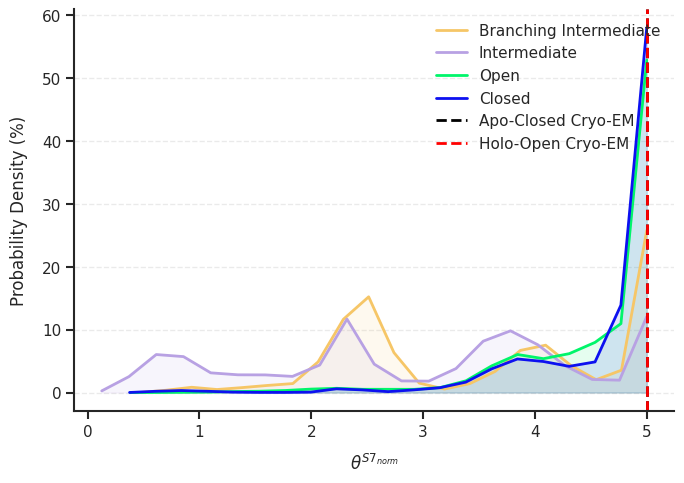

In [40]:
plot_all_distributions('helix', ['FES_1_helix.dat','FES_2_helix.dat','FES_3_helix.dat','FES_4_helix.dat'], ['Branching Intermediate','Intermediate','Open','Closed'])

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


<Figure size 1200x700 with 0 Axes>

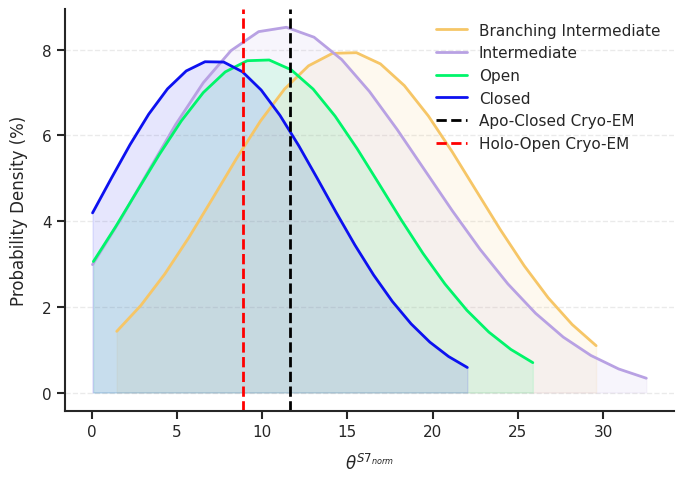

In [41]:
plot_all_distributions('angle', ['FES_1_angle.dat','FES_2_angle.dat','FES_3_angle.dat','FES_4_angle.dat'],['Branching Intermediate','Intermediate','Open','Closed'])

+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


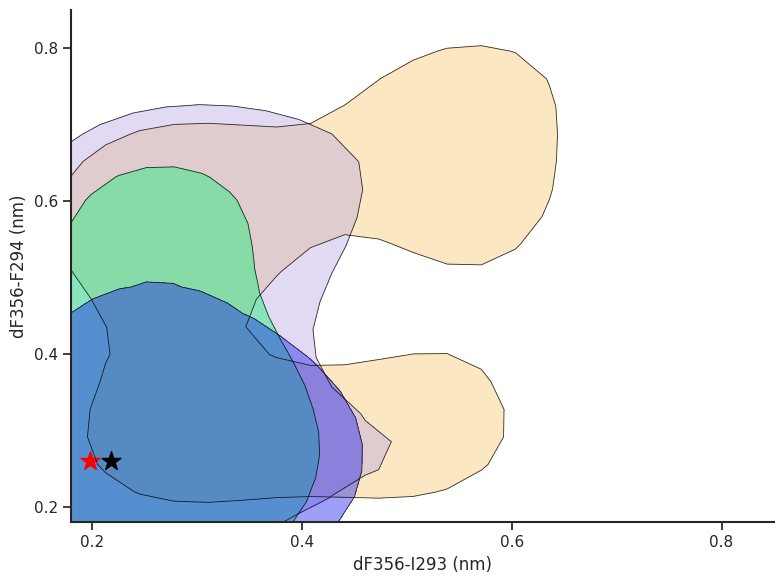

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plumed


def plot_all_2distributions(
    cv_names,
    filenames,
    indices,
    output_file="2CV_distributions.pdf"
):

    kb = 0.0083145
    T = 310
    kbT = kb * T

    colors = [
        "#F6C667",  # soft gold
        "#B8A1E3",  # lavender
        "#00F56A",  # mint
        "#0D11F0",  # blue
    ]

    sns.set_theme(style="ticks")

    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.size': 12,
        'axes.linewidth': 1.5,
        'xtick.major.width': 1.5,
        'ytick.major.width': 1.5
    })

    # ==================================================
    # read cryo-EM references
    # ==================================================
    apo_start_file = plumed.read_as_pandas(
        "/workdir/AgOR10_28/AgOR10/AgOR10_apo/cuts1/COLVAR_S6-S7_start"
    )

    bound_start_file = plumed.read_as_pandas(
        "/workdir/AgOR10_28/AgOR10/AgOR10_bound/COLVAR_S6-S7_start"
    )

    n_cv = len(cv_names)
    files_per_cv = len(indices)

    if len(filenames) != n_cv * files_per_cv:
        raise ValueError(
            f"Expected {n_cv * files_per_cv} files "
            f"but got {len(filenames)}."
        )

    # ==================================================
    # figure
    # ==================================================
    fig, axes = plt.subplots(
        n_cv,
        1,
        figsize=(7, 4),
        sharex=True,
        sharey=True
    )

    if n_cv == 1:
        axes = [axes]

    # ==================================================
    # loop over CVs
    # ==================================================
    for j, cv_name in enumerate(cv_names):

        ax = axes[j]

        apo_start = apo_start_file[cv_name].iloc[0]
        bound_start = bound_start_file[cv_name].iloc[0]

        cv_files = filenames[
            j * files_per_cv:
            (j + 1) * files_per_cv
        ]

        for i, filename in enumerate(cv_files):

            file_path = (
                f"/workdir/AgOR10_28/AgOR10/PCCA2/FES/{filename}"
            )

            if not os.path.exists(file_path):
                print(f"Missing file: {file_path}")
                continue

            data = plumed.read_as_pandas(file_path)

            prob = np.exp(
                -data["file.free"].values / kbT
            )

            prob = prob / np.sum(prob) * 100

            cv_values = data[cv_name].values

            if cv_name == "angle":
                cv_values = cv_values / np.pi * 180

            order = np.argsort(cv_values)

            ax.plot(
                cv_values[order],
                prob[order],
                lw=2,
                color=colors[i],
                label=indices[i]
            )

            ax.fill_between(
                cv_values[order],
                prob[order],
                color=colors[i],
                alpha=0.15
            )

        # ==========================================
        # Cryo-EM reference structures
        # ==========================================
        if cv_name == "angle":
            apo_start = apo_start / np.pi * 180
            bound_start = bound_start / np.pi * 180

        ax.axvline(
            apo_start,
            color="black",
            linestyle="--",
            linewidth=2,
            label="Apo-Closed Cryo-EM"
        )

        ax.axvline(
            bound_start,
            color="red",
            linestyle="--",
            linewidth=2,
            label="Holo-Open Cryo-EM"
        )

        # ==========================================
        # axis settings
        # ==========================================
        ax.set_xlim(0.18, 0.9)
        ax.set_ylim(0, 14)

        ax.set_xticks([0.2, 0.4, 0.6,0.8])
        ax.set_yticks([0, 4, 8, 12])

        ax.tick_params(
            axis='both',
            direction='out',
            length=5,
            width=1.5
        )


    # ==================================================
    # common labels
    # ==================================================
    fig.supylabel(
        "Probability Density (%)",
        fontsize=13
    )

    axes[-1].set_xlabel(
        "Distance (nm)",
        fontsize=13
    )

    sns.despine()

    plt.tight_layout()

    plt.savefig(
        output_file,
        dpi=300,
        transparent=True,
        bbox_inches='tight'
    )

    plt.show()
plot_all_2distributions(
    cv_names=[
        "d_A_PHE356_A_ILE293.min",
        "d_A_PHE356_A_PHE294.min"
    ],

    filenames=[
        # CV1
        "FES_S6-S71_d_A_PHE356_A_ILE293.min.dat",
        "FES_S6-S72_d_A_PHE356_A_ILE293.min.dat",
        "FES_S6-S73_d_A_PHE356_A_ILE293.min.dat",
        "FES_S6-S74_d_A_PHE356_A_ILE293.min.dat",

        # CV2
        "FES_S6-S71_d_A_PHE356_A_PHE294.min.dat",
        "FES_S6-S72_d_A_PHE356_A_PHE294.min.dat",
        "FES_S6-S73_d_A_PHE356_A_PHE294.min.dat",
        "FES_S6-S74_d_A_PHE356_A_PHE294.min.dat",
    ],

    indices=[
        "Branching Intermediate",
        "Intermediate",
        "Open",
        "Closed"
    ]
)


+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++
+++ Loading the PLUMED kernel runtime +++
+++ PLUMED_KERNEL="/usr/local/lib/libplumedKernel.so" +++


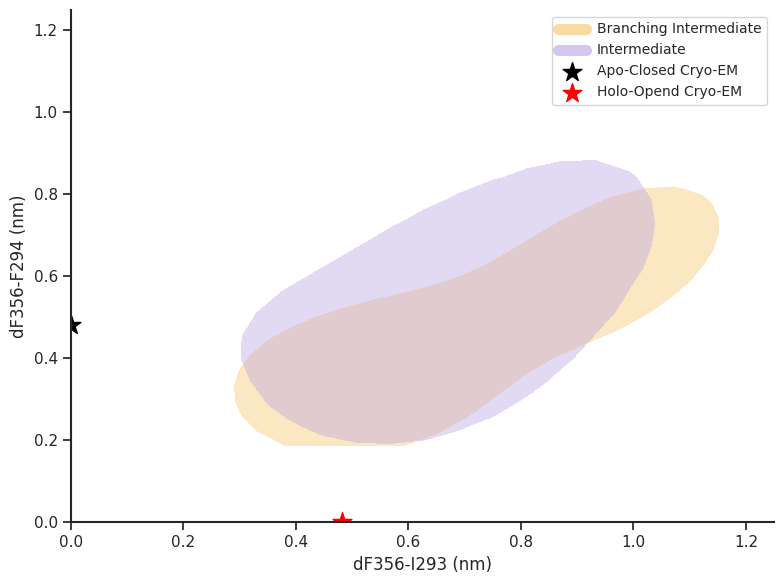

In [ ]:
from cProfile import label
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import plumed
from matplotlib.colors import LinearSegmentedColormap

def create_alpha_cmap(color, name='custom_cmap'):
    """
    创建一个从完全透明到指定颜色的渐变色板 (Colormap)。
    """
    # 获取颜色的 RGB 值
    rgb = plt.get_cmap('viridis').colors[0] # 默认占位
    if isinstance(color, str):
        rgb = plt.cm.colors.to_rgb(color)
    elif isinstance(color, (tuple, list, np.ndarray)):
        rgb = color[:3] # 确保只取 RGB，不管 A

    # 定义渐变：从透明到该颜色
    cdict = {
        'red':   [[0.0,  rgb[0], rgb[0]], [1.0, rgb[0], rgb[0]]],
        'green': [[0.0,  rgb[1], rgb[1]], [1.0, rgb[1], rgb[1]]],
        'blue':  [[0.0,  rgb[2], rgb[2]], [1.0, rgb[2], rgb[2]]],
        # 关键在于 Alpha 通道的渐变：从 0 (透明) 到 0.8 (大部分饱和)
        'alpha': [[0.0,  0.0, 0.0], [1.0, 0.8, 0.8]] 
    }
    return LinearSegmentedColormap(name, cdict)

def plot_all_distributions_2d(cv_names, indices, labels, output_file='dF356-F294_2D_filled.pdf'):
    # ... 基础参数设置保持不变 ...
    kb, T = 0.0083145, 310
    kbT = kb * T
    sns.set_theme(style="ticks")
    plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 12, 'axes.linewidth': 1.5})

    fig, ax = plt.subplots(figsize=(8, 6))
  
    label_to_fill_with_gradient = labels

    fill_levels = np.linspace(0.3, 2.0, 2) 
    line_levels = np.linspace(0.3, 2.0, 2)

    colors = [
    "#F6C667",  # soft gold
    "#B8A1E3",  # light lavender
        ]
    for i, index in enumerate(indices):
        file_path = f"/workdir/AgOR10_28/AgOR10/PCCA2/FES/{index}"
        if not os.path.exists(file_path): continue
        
        label = labels[i]   
        data = plumed.read_as_pandas(file_path)
        
        # 数据处理
        fe = data['file.free'].values
        prob = np.exp(-fe / kbT)
        prob = prob / np.sum(prob) * 100
        x, y = data[cv_names[0]].values, data[cv_names[1]].values
        n_x, n_y = len(np.unique(x)), len(np.unique(y))
        X, Y, Z = x.reshape(n_y, n_x), y.reshape(n_y, n_x), prob.reshape(n_y, n_x)

        current_base_color = colors[i]

        if label in label_to_fill_with_gradient:

            state_specific_cmap = create_alpha_cmap(current_base_color)

            cf = ax.contourf(X, Y, Z, levels=fill_levels, cmap=state_specific_cmap, extend='max',alpha=0.4)
            
        
            ax.plot([], [], color=current_base_color, label=f'{label}', linewidth=8, alpha=0.6)
        
        else:
            CS = ax.contour(X, Y, Z, levels=line_levels, colors=[current_base_color], linewidths=1.5,alpha=0.7)

        
    ax.scatter(0,0.482243,s=200, c='black', marker='*', label='Apo-Closed Cryo-EM')
    ax.scatter(0.482243,0,s=200, c='red', marker='*', label='Holo-Opend Cryo-EM')
    ax.set_xlabel('RMSD to Closed (nm)')
    ax.set_ylabel('RMSD to Open (nm)')

    ax.set_ylabel('dF356-F294 (nm)')
    ax.set_xlabel('dF356-I293 (nm)')
    ax.legend(loc='upper right', frameon=True, fontsize=10)
    ax.set_xlim(0, 1.25)
    ax.set_ylim(0, 1.25)
    plt.tight_layout()
    sns.despine()
    plt.savefig(output_file, dpi=300, transparent=True)
    plt.show()
cv_names = ['open_rmsd','close_rmsd']
plot_all_distributions_2d(cv_names, 
                          ['FES_S6_upper1_open_rmsd,close_rmsd.dat','FES_S6_upper2_open_rmsd,close_rmsd.dat'],
                          ['Branching Intermediate','Intermediate'],'S6rmsd.pdf')